/tmp/ipykernel_2556/1797675689.py:52: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)


/opt/hostedtoolcache/Python/3.12.14/x64/lib/python3.12/site-packages/alphalens/utils.py:308: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = prices.pct_change(period)
/opt/hostedtoolcache/Python/3.12.14/x64/lib/python3.12/site-packages/alphalens/utils.py:308: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = prices.pct_change(period)
/opt/hostedtoolcache/Python/3.12.14/x64/lib/python3.12/site-packages/alphalens/utils.py:308: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leadin

Dropped 0.4% entries from factor data: 0.4% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 100.0%, not exceeded: OK!
Quantiles Statistics


,min,max,mean,std,count,count %
factor_quantile,,,,,,
1,-25.697218,-0.036757,-0.267231,0.618480,19021,20.152353
2,-1.335798,-0.024548,-0.112365,0.125934,18797,19.915030
3,-0.901478,-0.017265,-0.075542,0.081802,18832,19.952112
4,-0.635600,-0.011995,-0.048328,0.047073,18797,19.915030
5,-0.404254,-0.001599,-0.025841,0.025613,18939,20.065476


Returns Analysis


,1D,5D,10D
Ann. alpha,0.157,0.106,0.109
beta,-0.097,-0.096,-0.083
Mean Period Wise Return Top Quantile (bps),2.122,4.108,3.955
Mean Period Wise Return Bottom Quantile (bps),-6.985,-5.287,-4.954
Mean Period Wise Spread (bps),9.107,9.525,9.066


<Figure size 640x480 with 0 Axes>

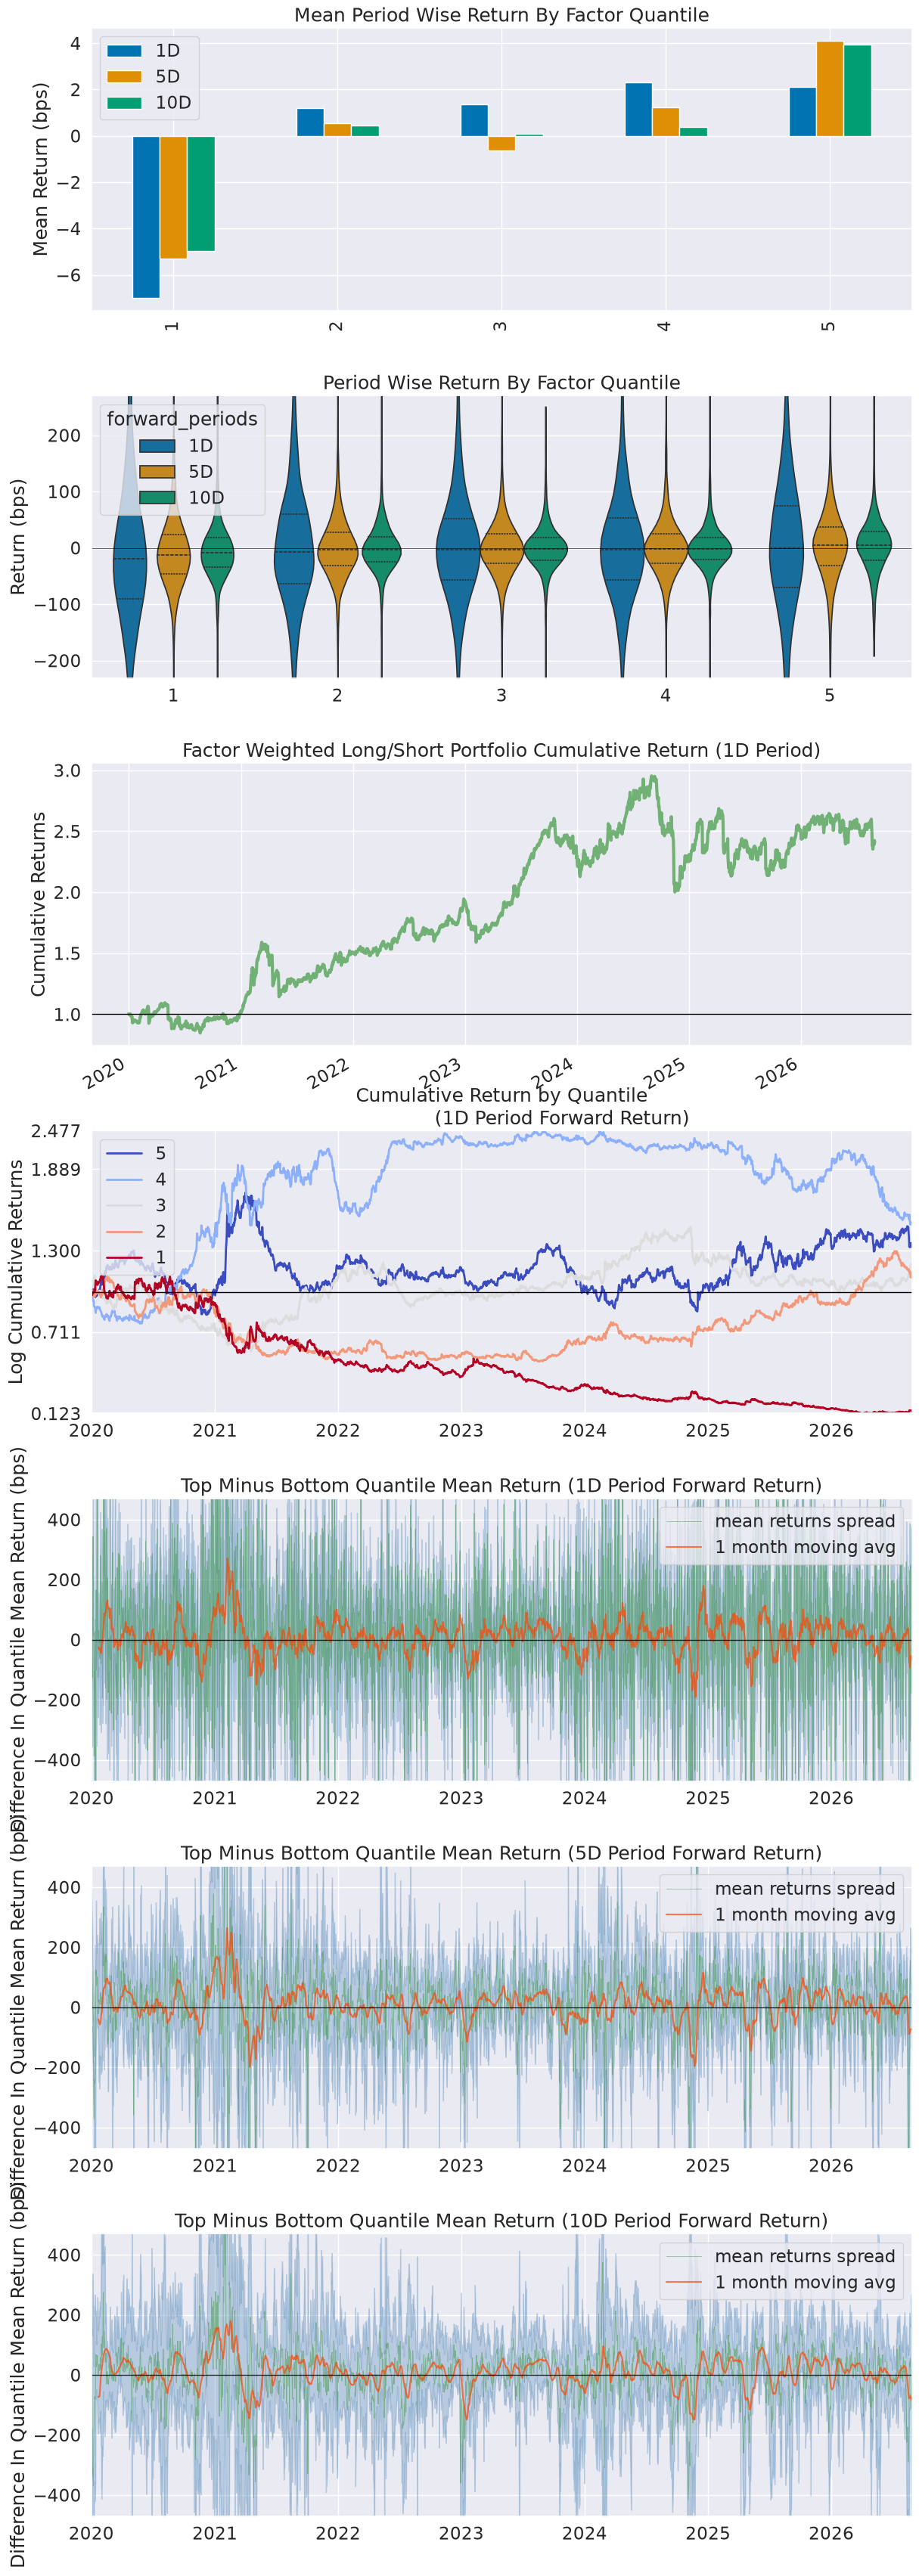

Information Analysis


,1D,5D,10D
IC Mean,0.041,0.058,0.067
IC Std.,0.235,0.232,0.229
Risk-Adjusted IC,0.177,0.248,0.291
t-stat(IC),8.706,12.246,14.343
p-value(IC),0.000,0.000,0.000
IC Skew,-0.051,-0.080,-0.110
IC Kurtosis,-0.285,-0.312,-0.374


/opt/hostedtoolcache/Python/3.12.14/x64/lib/python3.12/site-packages/alphalens/performance.py:118: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  grouper.append(pd.Grouper(freq=by_time))


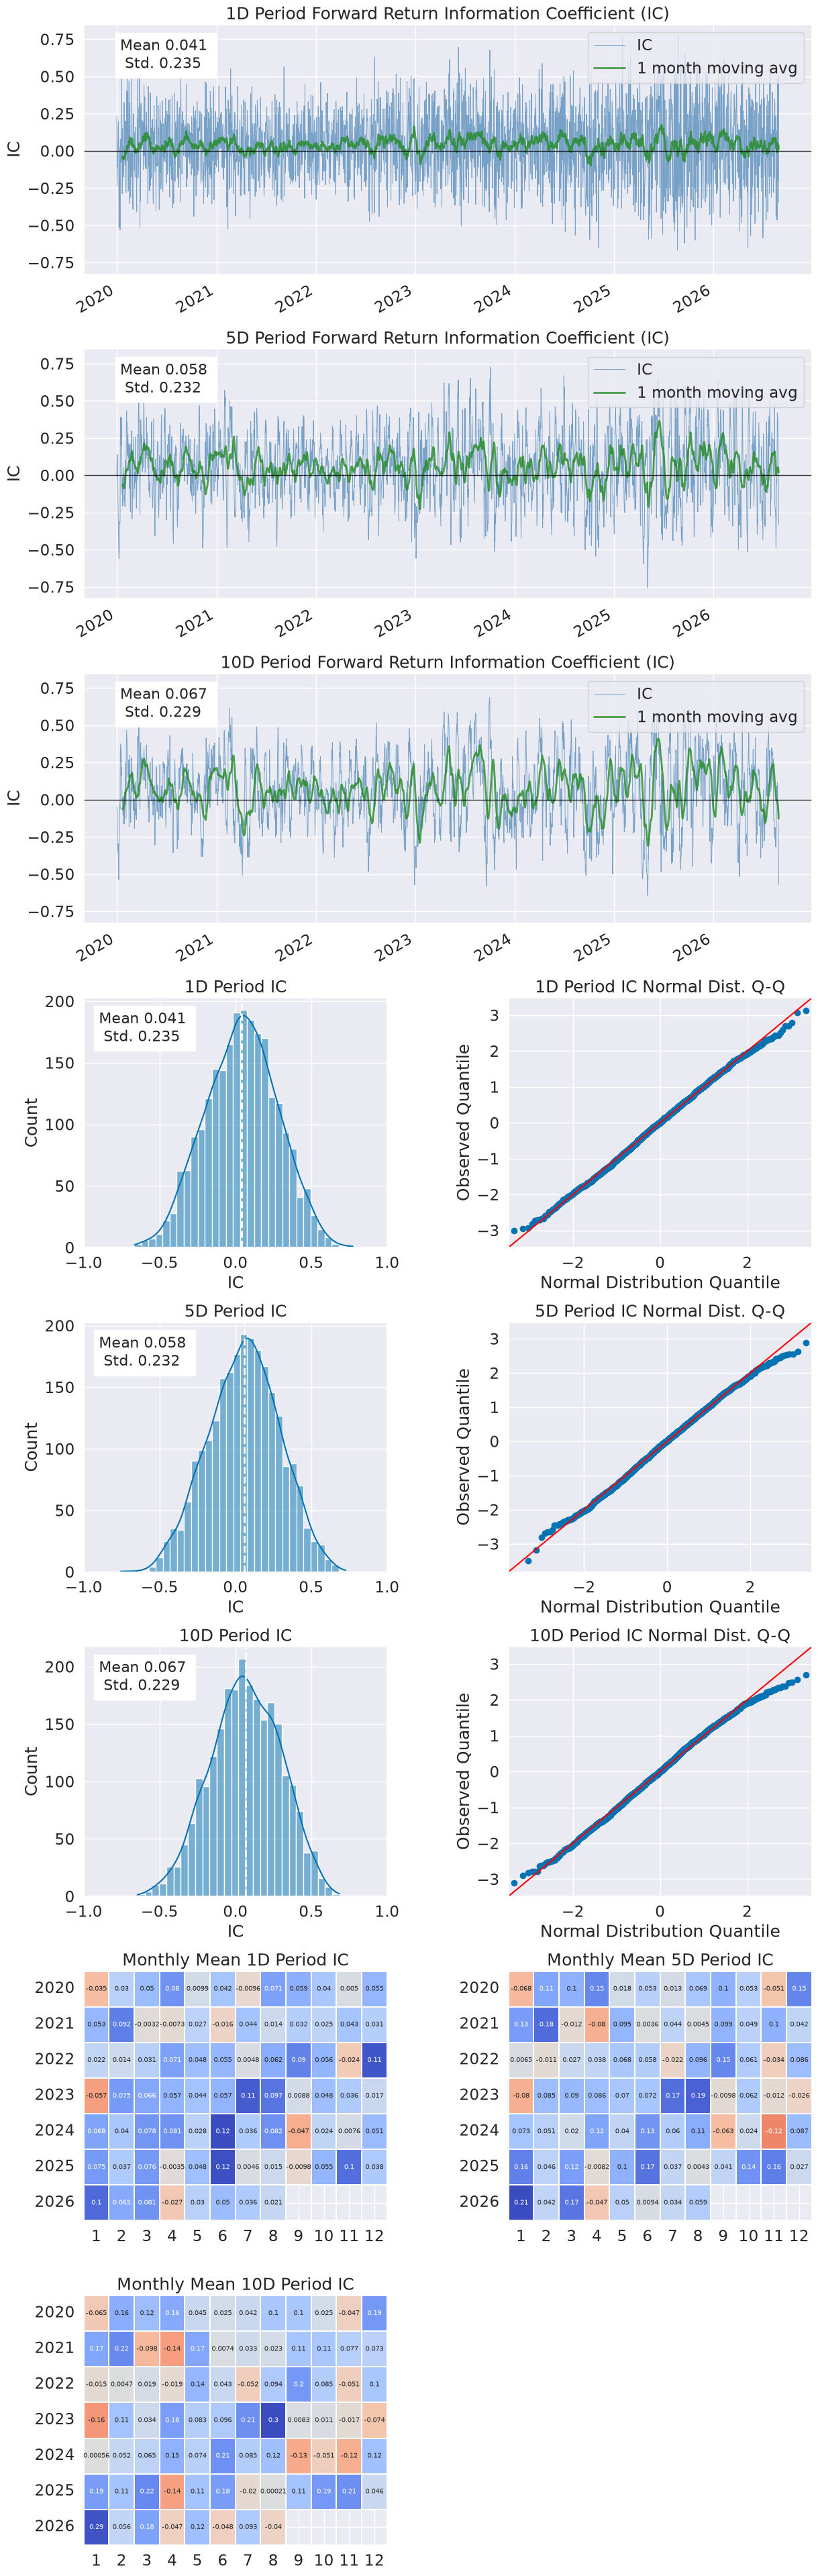

/opt/hostedtoolcache/Python/3.12.14/x64/lib/python3.12/site-packages/alphalens/utils.py:928: UserWarning: Skipping return periods that aren't exact multiples of days.
  warnings.warn(


Turnover Analysis


,1D,5D,10D
Quantile 1 Mean Turnover,0.168,0.282,0.346
Quantile 2 Mean Turnover,0.305,0.437,0.494
Quantile 3 Mean Turnover,0.324,0.450,0.503
Quantile 4 Mean Turnover,0.287,0.401,0.450
Quantile 5 Mean Turnover,0.136,0.212,0.257


,1D,5D,10D
Mean Factor Rank Autocorrelation,0.961,0.921,0.901


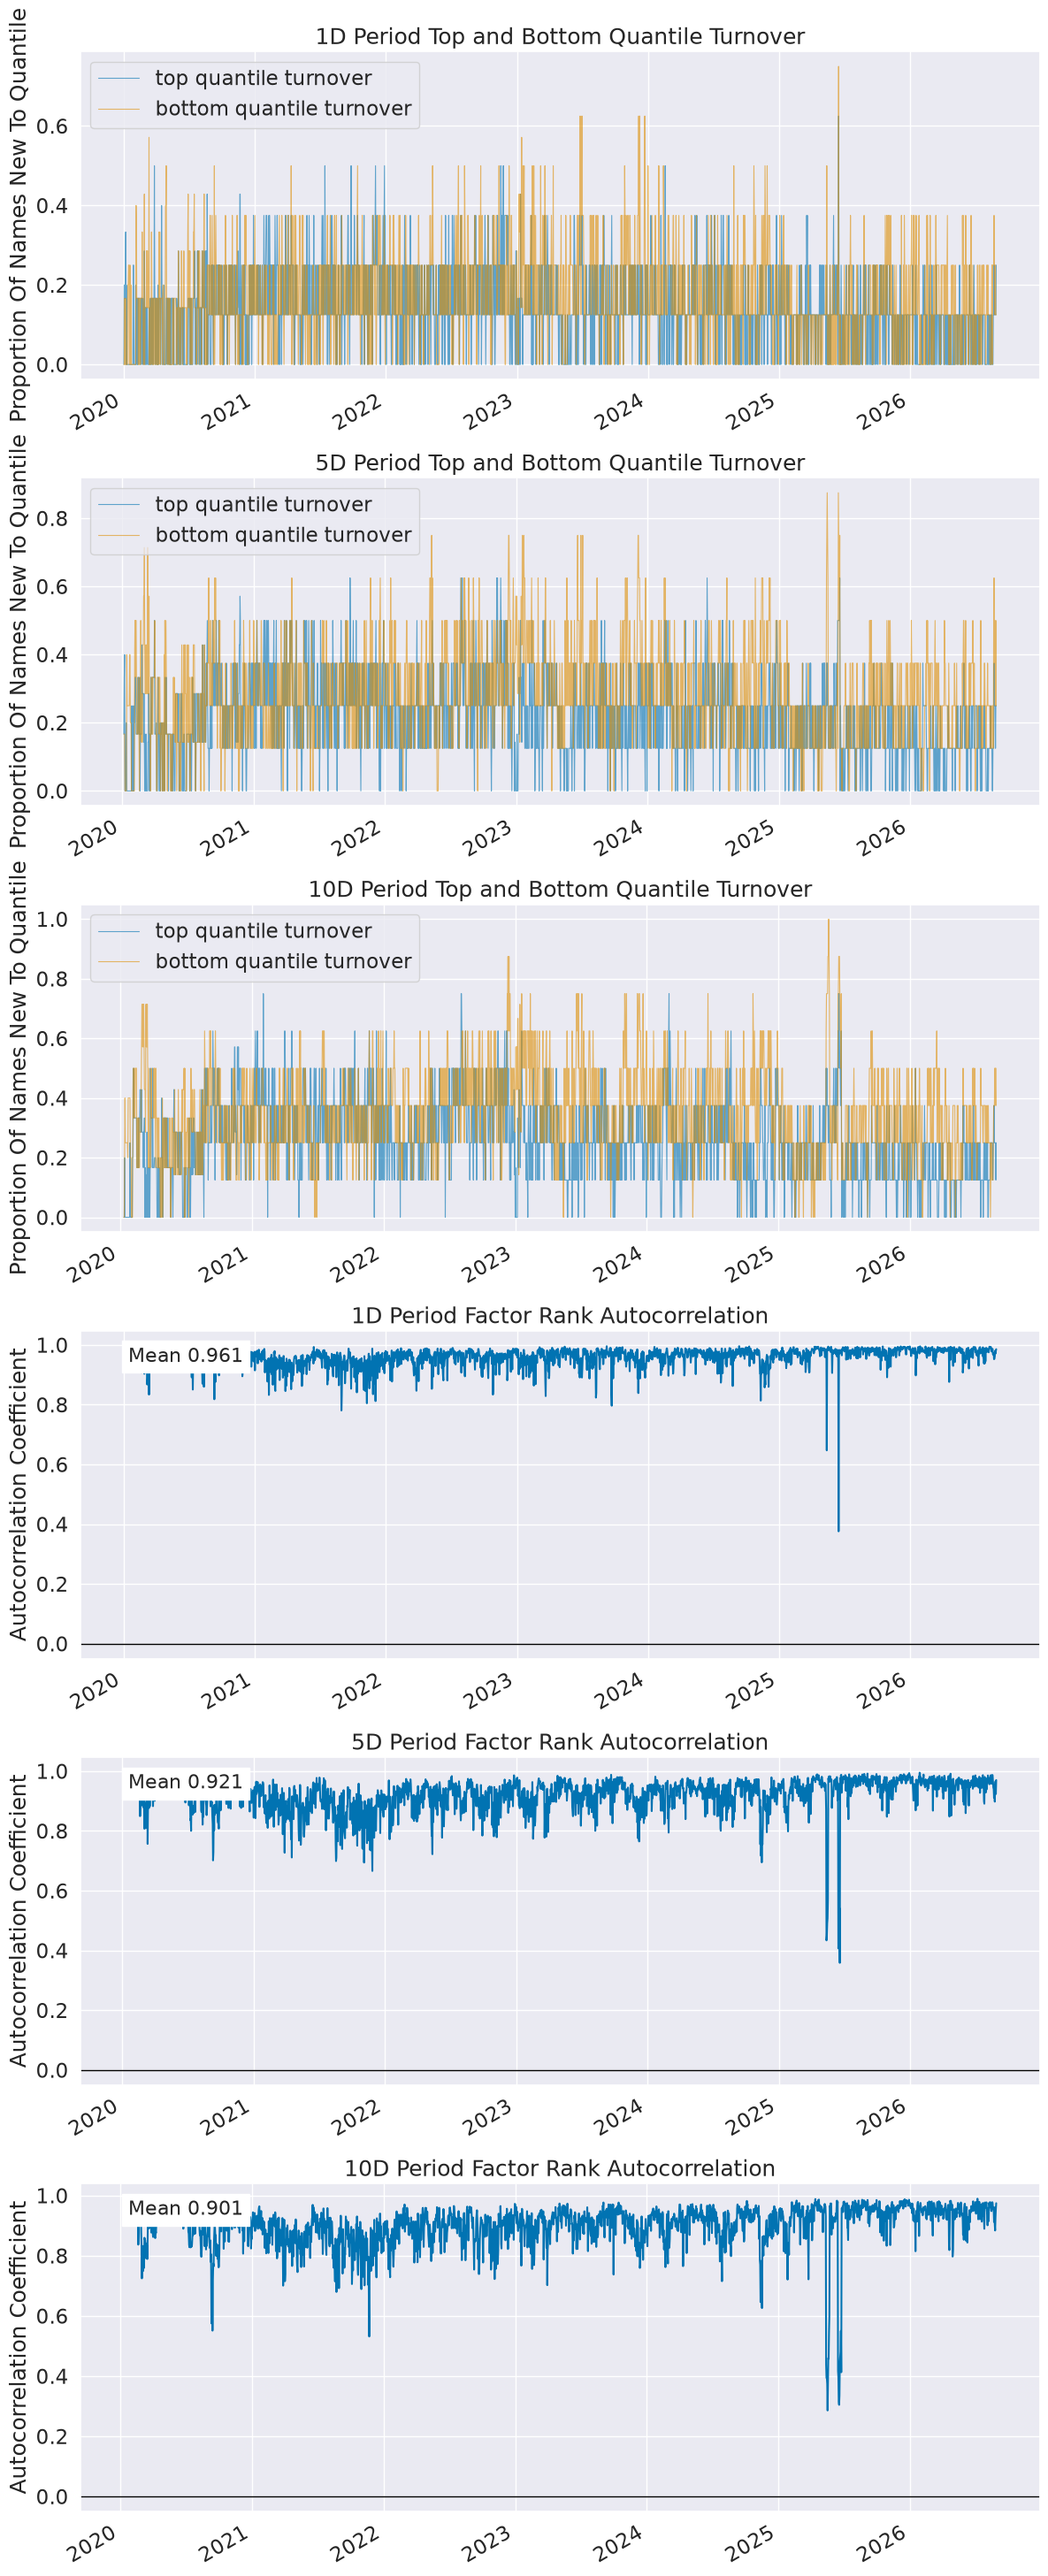

In [1]:
# AUTO-GENERATED from scripts/factors_catalog.py by
# scripts/generate_factor_notebooks.py -- do not edit by hand.
import sys
from pathlib import Path

_root = Path.cwd()
while not (_root / "notebooks" / "analysis").is_dir() and _root != _root.parent:
    _root = _root.parent
for _p in (_root, _root / "notebooks"):
    sys.path.insert(0, str(_p))

from unravel_client import (
    get_historical_universe,
    get_portfolio_factors_historical,
    get_prices,
    get_tickers,
)

from analysis.alphalens import factor_analysis
from analysis.utils import get_env

UNRAVEL_API_KEY = get_env("UNRAVEL_API_KEY")

# Relative Illiquidity -- portfolio relative_illiquidity.40
portfolio = "relative_illiquidity"
universe_size = "40"

available_tickers = get_tickers(
    id=portfolio,
    api_key=UNRAVEL_API_KEY,
    universe_size=universe_size,
    exchange=None,
)
historical_factors = get_portfolio_factors_historical(
    id=portfolio, tickers=available_tickers, api_key=UNRAVEL_API_KEY
)
underlying = get_prices(tickers=available_tickers, api_key=UNRAVEL_API_KEY)

# Mask the raw factor with the dynamic point-in-time universe (a boolean
# dates x tickers matrix) so AlphaLens scores only the universe we trade,
# not every ticker that was ever tradeable.
universe = get_historical_universe(
    size=universe_size,
    api_key=UNRAVEL_API_KEY,
    start_date=str(historical_factors.index.min().date()),
    end_date=str(historical_factors.index.max().date()),
)
membership = (
    universe.reindex(index=historical_factors.index)
    .ffill()
    .reindex(columns=historical_factors.columns)
    .fillna(False)
    .astype(bool)
)
restricted_factors = historical_factors.where(membership)

columns_intersection = restricted_factors.columns.intersection(underlying.columns)
factor_analysis(restricted_factors[columns_intersection], underlying)